In [1]:
import pandas as pd
import glob
files = glob.glob("*.csv")
df_list = []
for file in files:
    temp = pd.read_csv(file)
    year = file.split(".")[0]
    temp['year'] = int(year)
    df_list.append(temp)
df = pd.concat(df_list, ignore_index=True)
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing:
The datasets from different years had inconsistent column names and formats. 
To ensure consistency, all columns were standardized into a unified schema 

Duplicate columns were removed, and missing values such as region information were handled appropriately. 
This preprocessing step ensured accurate and reliable analysis across all years.

In [14]:
df.rename(columns={

    # Country
    'Country': 'Country name',
    'Country or region': 'Country name',

    # Happiness Score
    'Happiness Score': 'Happiness Score',
    'Happiness.Score': 'Happiness Score',
    'Score': 'Happiness Score',

    # GDP
    'Economy (GDP per Capita)': 'Log GDP per capita',
    'Economy..GDP.per.Capita.': 'Log GDP per capita',
    'GDP per capita': 'Log GDP per capita',

    # Social support
    'Family': 'Social support',
    'Social support': 'Social support',

    # Health
    'Health (Life Expectancy)': 'Healthy life expectancy',
    'Health..Life.Expectancy.': 'Healthy life expectancy',
    'Healthy life expectancy': 'Healthy life expectancy',

    # Freedom
    'Freedom': 'Freedom to make life choices',

    # Corruption
    'Trust (Government Corruption)': 'Perceptions of corruption',
    'Trust..Government.Corruption.': 'Perceptions of corruption',

}, inplace=True)

#Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

#Strip spaces
df.columns = df.columns.str.strip()

#Ensure required columns exist
required_cols = [
    'Country name', 'Region', 'Happiness Score',
    'Log GDP per capita', 'Social support',
    'Healthy life expectancy', 'Freedom to make life choices',
    'Generosity', 'Perceptions of corruption', 'year'
]

# Add missing Region (for 2017, 2018, 2019)
if 'Region' not in df.columns:
    df['Region'] = 'Unknown'

# Keep only required columns
df = df[[col for col in required_cols if col in df.columns]]

#Clean values
df['Country name'] = df['Country name'].str.strip().str.lower()
df['year'] = df['year'].astype(int)

df.head()

,Country name,Region,Happiness Score,Log GDP per capita,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,switzerland,Western Europe,7.587,1.39651,0.94143,0.66557,0.29678,0.41978,2015
1,iceland,Western Europe,7.561,1.30232,0.94784,0.62877,0.43630,0.14145,2015
2,denmark,Western Europe,7.527,1.32548,0.87464,0.64938,0.34139,0.48357,2015
3,norway,Western Europe,7.522,1.45900,0.88521,0.66973,0.34699,0.36503,2015
4,canada,North America,7.427,1.32629,0.90563,0.63297,0.45811,0.32957,2015


# Q1. Happiness Score Analysis by Region
## Explanation:
In this task, we create a Pandas Series using the Happiness Score with country names as the index.
We then group the data by region and calculate the standard deviation to measure variation 
### Code Explanation:
- set_index() is used to assign country names as index.
- groupby() groups data by region.
- std() calculates variation in happiness scores.

In [8]:
# Create Series
happiness_series = pd.Series(df['Happiness Score'].values, index=df['Country name'])
happiness_series.head()
# Variation by region
region_variation = df.groupby('Region')['Happiness Score'].std().sort_values(ascending=False)
region_variation

Region
Middle East and Northern Africa    1.066028
Southeastern Asia                  0.912392
Western Europe                     0.797179
Latin America and Caribbean        0.719259
Sub-Saharan Africa                 0.582399
Central and Eastern Europe         0.575707
Southern Asia                      0.570575
Eastern Asia                       0.515481
North America                      0.175872
Australia and New Zealand          0.023838
Name: Happiness Score, dtype: float64

# Insight:
Regions with higher standard deviation show greater inequality in happiness levels.
Regions with lower variation indicate more uniform living conditions and stability.

# Q2. Correlation Between GDP and Happiness

This analysis examines the relationship between GDP per capita and happiness score.
We also compare multiple contributing factors to understand whether wealth alone determines happine
### Code Explanation:
- corr() computes correlation between variables.
- Multiple features are analyzed together.ss.

In [15]:
# Correlation with GDP
corr = df['Log GDP per capita'].corr(df['Happiness Score'])
print("GDP vs Happiness Correlation:", corr)
# Multiple factors
factors = df[['Happiness Score', 'Log GDP per capita',
              'Healthy life expectancy',
              'Freedom to make life choices',
              'Generosity']]
display(factors.corr())

GDP vs Happiness Correlation: 0.779171095112871


,Happiness Score,Log GDP per capita,Healthy life expectancy,Freedom to make life choices,Generosity
Happiness Score,1.000000,0.779171,0.734491,0.556414,0.168272
Log GDP per capita,0.779171,1.000000,0.789103,0.331127,-0.015402
Healthy life expectancy,0.734491,0.789103,1.000000,0.369799,0.088002
Freedom to make life choices,0.556414,0.331127,0.369799,1.000000,0.343389
Generosity,0.168272,-0.015402,0.088002,0.343389,1.000000


GDP per capita shows a strong positive correlation with happiness. However, factors like health and freedom also have significant influence, indicating that wealth alone is not sufficient to determine happiness.

## Q3. Year-wise Comparison using Index Alignment

### Explanation:
We compare happiness scores between t2015 and 2016ars.

### Code Explanation:
- pivot_table() aligns countries across years.
- Arithmetic subtraction calculates change.es.

In [22]:
# Select years
df_2015 = df[df['year'] == 2015].copy()
df_2016 = df[df['year'] == 2016].copy()

# Clean names (important)
df_2015['Country name'] = df_2015['Country name'].str.strip().str.lower()
df_2016['Country name'] = df_2016['Country name'].str.strip().str.lower()

# Keep common countries
common = set(df_2015['Country name']) & set(df_2016['Country name'])

df_2015 = df_2015[df_2015['Country name'].isin(common)]
df_2016 = df_2016[df_2016['Country name'].isin(common)]

# Create Series
s2015 = df_2015.set_index('Country name')['Happiness Score']
s2016 = df_2016.set_index('Country name')['Happiness Score']

# Difference
change = s2016 - s2015

display(change.sort_values(ascending=False).head())

Country name
algeria    0.750
togo       0.464
latvia     0.462
romania    0.404
hungary    0.345
Name: Happiness Score, dtype: float64

### Insight:
The results show that countries like Algeria and Togo experienced significant improvements in happiness scores between 2015 and 2016

This demonstrates how index alignment allows accurate comparison across years when country names are consistent.

## Q4. Hierarchical Indexing and Regional Analysis

### Explanation:
A hierarchical index is created using Region and Country name to organize the dataset into multiple levels.

### Code Explanation:
- set_index() creates a multi-level index.
- groupby(level=0) computes averages at the regional level.
- xs() extracts data for a specific region.

### Insight:
Hierarchical indexing enables efficient analysis at different levels. 
Regional averages provide insights into overall trends, while xs() allows detailed examination of individual regions. region.

In [25]:
# Create hierarchical index
df_multi = df.set_index(['Region', 'Country name'])

# Regional averages (level 0)
region_avg = df_multi.groupby(level=0)[[
    'Happiness Score',
    'Freedom to make life choices',
    'Generosity'
]].mean()

display(region_avg)

# Extract one region using xs()
region_name = df['Region'].dropna().unique()[0]

print("Selected Region:", region_name)

region_data = df_multi.xs(region_name, level='Region')
display(region_data.head())

,Happiness Score,Freedom to make life choices,Generosity
Region,,,
Australia and New Zealand,7.304250,0.610115,0.469677
Central and Eastern Europe,5.351810,0.329398,0.161581
Eastern Asia,5.625167,0.424886,0.224724
Latin America and Caribbean,6.122283,0.462560,0.212905
Middle East and Northern Africa,5.396744,0.336426,0.188609
North America,7.263500,0.558585,0.429567
Southeastern Asia,5.328167,0.523614,0.432706
Southern Asia,4.572071,0.361681,0.342355
Sub-Saharan Africa,4.170462,0.341332,0.223676


Selected Region: Western Europe


,Happiness Score,Log GDP per capita,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
Country name,,,,,,,
switzerland,7.587,1.39651,0.94143,0.66557,0.29678,0.41978,2015
iceland,7.561,1.30232,0.94784,0.62877,0.43630,0.14145,2015
denmark,7.527,1.32548,0.87464,0.64938,0.34139,0.48357,2015
norway,7.522,1.45900,0.88521,0.66973,0.34699,0.36503,2015
finland,7.406,1.29025,0.88911,0.64169,0.23351,0.41372,2015


## Q5. Handling Missing Values in 'Perceptions of Corruption'

### Explanation:
This task examines how missing values in the 'Perceptions of corruption' column affect the dataset.

### Code Explanation:
- fillna(mean) replaces missing values with the average of the column.
- forward fill (ffill) propagates the last valid value forward.
- interpolation estimates missing values based on surrounding data trends.

These methods are compared to determine which preserves statistical integrity.

In [27]:
col = 'Perceptions of corruption'

print("Missing values:", df[col].isnull().sum())

mean_fill = df[col].fillna(df[col].mean())
ffill = df[col].ffill()
interp = df[col].interpolate()

comparison = pd.DataFrame({
    'Original Mean': [df[col].mean()],
    'Mean Fill': [mean_fill.mean()],
    'Forward Fill': [ffill.mean()],
    'Interpolation': [interp.mean()]
})

display(comparison)

Missing values: 467


,Original Mean,Mean Fill,Forward Fill,Interpolation
0,0.140532,0.140532,0.112857,0.112857


### Insight:
The dataset contains a significant number of missing values in the 'Perceptions of corruption' column

Mean imputation preserves the overall average but reduces variability, which can distort statistical analyss.

Forward fill changes the mean and introduces bias by repeating previous values, making it less relible.

Interpolation provides a better estimate by considering surrounding values and preserving the datatrend.

Therefore, interpolation is the most suitable method as it maintains statistical integrity and reflects realistic variations in the data.

## Q6. Filtering Highly Happy Countries

### Explanation:
In this task, we use boolean indexing to filter countries with a happiness score greater than 7.0.

### Code Explanation:
- A condition (Happiness Score > 7.0) is applied to filter the dataset.
- The resulting subset contains only highly happy countries.
- describe() is used to compute summary statistics such as mean, standard deviation, and quartiles.edom.

In [29]:
# Filter countries with Happiness Score > 7
happy_countries = df[df['Happiness Score'] > 7.0]

print("Number of highly happy countries:", happy_countries.shape[0])

# Display first few rows
display(happy_countries.head())

# Descriptive statistics
display(happy_countries.describe())

Number of highly happy countries: 30


,Country name,Region,Happiness Score,Log GDP per capita,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,switzerland,Western Europe,7.587,1.39651,0.94143,0.66557,0.29678,0.41978,2015
1,iceland,Western Europe,7.561,1.30232,0.94784,0.62877,0.43630,0.14145,2015
2,denmark,Western Europe,7.527,1.32548,0.87464,0.64938,0.34139,0.48357,2015
3,norway,Western Europe,7.522,1.45900,0.88521,0.66973,0.34699,0.36503,2015
4,canada,North America,7.427,1.32629,0.90563,0.63297,0.45811,0.32957,2015


,Happiness Score,Log GDP per capita,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,7.336533,1.351551,0.856218,0.577319,0.361932,0.288437,2015.500000
std,0.155073,0.140005,0.051446,0.074508,0.094029,0.130907,0.508548
min,7.039000,0.955780,0.761460,0.364320,0.140740,0.077850,2015.000000
25%,7.236250,1.325683,0.812843,0.552145,0.303305,0.152037,2015.000000
50%,7.336500,1.360045,0.861030,0.581825,0.362165,0.320725,2015.500000
75%,7.480250,1.443768,0.892235,0.633563,0.445330,0.411533,2016.000000
max,7.587000,1.577440,0.947840,0.669730,0.494010,0.483570,2016.000000


### Insight:
Countries with happiness scores above 7.0 generally exhibit higher GDP per capita, better health conditions, and greater freedom of choice.
The descriptive statistics show that these countries have consistently high values across key contributing factors such as life expectancy and social support.
This suggests that happiness is strongly associated with overall quality of life, including economic stability, healthcare, and personal freedom.

## Q7. Composite Well-Being Index

### Explanation:
In this task, we create a composite Well-Being Index by combining multiple factors:
- GDP per capita
- Healthy life expectancy
- Freedom to make life choices
- Generosity

### Code Explanation:
- Min-max normalization is applied using vectorized operations (ufuncs).
- This scales all features between 0 and 1.
- The mean of normalized values is computed to form a composite index.
- Countries are ranked based on this index.

In [30]:
features = [
    'Log GDP per capita',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity'
]

# Normalize using vectorized operations (ufuncs)
norm_df = (df[features] - df[features].min()) / (df[features].max() - df[features].min())

# Create Well-Being Index
df['Well-Being Index'] = norm_df.mean(axis=1)

# Create leaderboard
leaderboard = df[['Country name', 'Well-Being Index']].sort_values(
    by='Well-Being Index', ascending=False
)

display(leaderboard.head(10))

,Country name,Well-Being Index
428,myanmar,0.884104
9,australia,0.782954
341,malta,0.782443
71,hong kong,0.777297
4,canada,0.775521
346,thailand,0.774492
1,iceland,0.774455
8,new zealand,0.773193
20,united kingdom,0.772729
6,netherlands,0.771776


### Insight:
The Well-Being Index provides a balanced measure of a country's overall quality of life by combining economic, health, and social factors

Countries with high rankings in this index consistently perform well across multiple dimensions, not just GP.

This demonstrates that happiness and well-being are multi-dimensional and cannot be explained by a single factor alone.

## Q8. Impact of Dropping vs Imputing Missing Values

### Explanation:
In this task, we analyze how handling missing values affects regional happiness rankings.

### Code Explanation:
- dropna() removes rows with missing values, reducing dataset size.
- fillna() replaces missing values with the mean, preserving dataset size.
- groupby() is used to compute average happiness scores by region.
- Results are compared before and after handling missing data.

In [31]:
# Original regional averages
original_avg = df.groupby('Region')['Happiness Score'].mean()

# Drop missing values
drop_df = df.dropna()
drop_avg = drop_df.groupby('Region')['Happiness Score'].mean()

# Fill missing values with mean
fill_df = df.fillna(df.mean(numeric_only=True))
fill_avg = fill_df.groupby('Region')['Happiness Score'].mean()

# Combine results
comparison = pd.DataFrame({
    'Original': original_avg,
    'After Dropna': drop_avg,
    'After Fillna': fill_avg
})

display(comparison)

,Original,After Dropna,After Fillna
Region,,,
Australia and New Zealand,7.304250,7.304250,7.304250
Central and Eastern Europe,5.351810,5.351810,5.351810
Eastern Asia,5.625167,5.625167,5.625167
Latin America and Caribbean,6.122283,6.122283,6.122283
Middle East and Northern Africa,5.396744,5.396744,5.396744
North America,7.263500,7.263500,7.263500
Southeastern Asia,5.328167,5.328167,5.328167
Southern Asia,4.572071,4.572071,4.572071
Sub-Saharan Africa,4.170462,4.170462,4.170462


### Insight:
Dropping missing values reduces the dataset size and may remove important information, which can slightly alter regional averages

Filling missing values with the mean preserves the dataset size but may smooth out variations, reducing the accuracy of real-world differencs.

Comparing the tables shows that while overall trends remain similar, some regional rankings shift depending on the method sed.

This demonstrates that data preprocessing decisions can significantly impact analytical results and must be chosen carefully.

## Q9. Comparison Between Top and Bottom 20 Countries

### Explanation:
In this task, we compare the top 20 happiest countries with the bottom 20 countries.

### Code Explanation:
- nlargest() selects the top 20 happiest countries.
- nsmallest() selects the bottom 20 countries.
- set_index() aligns both DataFrames by country name.
- Arithmetic subtraction is used to examine differences in contributing factors.

In [32]:
# Select top and bottom 20 countries
top20 = df.nlargest(20, 'Happiness Score')
bottom20 = df.nsmallest(20, 'Happiness Score')

# Select important features
features = [
    'Happiness Score',
    'Log GDP per capita',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity'
]

# Set index for alignment
top20 = top20.set_index('Country name')[features]
bottom20 = bottom20.set_index('Country name')[features]

# Compute average values
top_avg = top20.mean()
bottom_avg = bottom20.mean()

# Difference
difference = top_avg - bottom_avg

display(difference.to_frame(name="Difference"))

,Difference
Happiness Score,4.028300
Log GDP per capita,1.092334
Healthy life expectancy,0.584818
Freedom to make life choices,0.292331
Generosity,0.134223


### Insight:
The comparison shows that top 20 happiest countries significantly outperform bottom 20 countries across all key factors.
The largest differences are observed in GDP per capita and healthy life expectancy, indicating that economic strength and health play a major role in happiness.
Freedom and generosity also contribute, but their differences are relatively smaller.
This analysis highlights that happiness is strongly influenced by a combination of economic and social factors.

## Q10. Multi-Level Regional Analysis Across Years

### Explanation:
In this task, we create a multi-level grouped report to analyze average happiness scores across regions for different years.

### Code Explanation:
- pivot_table() is used to compute average values.
- 'Region' is used as the index.
- 'year' is used as columns to compare across time.
- This creates a structured table for comparative analysis.

Happiness Score            \
year                                       2015      2016   
Region                                                      
Australia and New Zealand              7.285000  7.323500   
Central and Eastern Europe             5.332931  5.370690   
Eastern Asia                           5.626167  5.624167   
Latin America and Caribbean            6.144682  6.101750   
Middle East and Northern Africa        5.406900  5.386053   
North America                          7.273000  7.254000   
Southeastern Asia                      5.317444  5.338889   
Southern Asia                          4.580857  4.563286   
Sub-Saharan Africa                     4.202800  4.136421   
Western Europe                         6.689619  6.685667   

                                Healthy life expectancy            \
year                                               2015      2016   
Region                                                              
Australia and New Zealand                      0.919965  0.841080   
Central and Eastern Europe                     0.718774  0.631592   
Eastern Asia                                   0.877388  0.806680   
Latin America and Caribbean                    0.703870  0.612703   
Middle East and Northern Africa                0.705615  0.616438   
North America                                  0.883710  0.803300   
Southeastern Asia                              0.677357  0.561369   
Southern Asia                                  0.540830  0.453670   
Sub-Saharan Africa                             0.282332  0.239872   
Western Europe                                 0.909148  0.825754   

                                Log GDP per capita            
year                                          2015      2016  
Region                                                        
Australia and New Zealand                 1.291880  1.402545  
Central and Eastern Europe                0.942438  1.047537  
Eastern Asia                              1.151780  1.277312  
Latin America and Caribbean               0.876815  0.993410  
Middle East and Northern Africa           1.066974  1.139323  
North America                             1.360400  1.474055  
Southeastern Asia                         0.789054  0.896381  
Southern Asia                             0.560486  0.660671  
Sub-Saharan Africa                        0.380473  0.474321  
Western Europe                            1.298596  1.417056

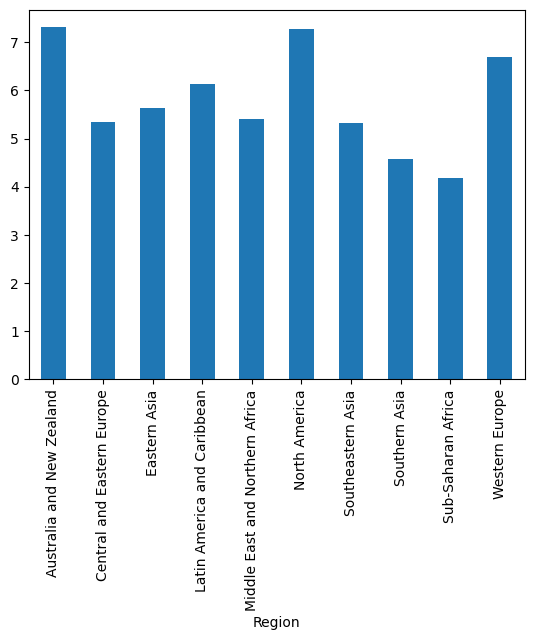

In [34]:
pivot = pd.pivot_table(
    df,
    values=['Happiness Score',
            'Log GDP per capita',
            'Healthy life expectancy'],
    index='Region',
    columns='year',
    aggfunc='mean'
)
df.groupby('Region')['Happiness Score'].mean().plot(kind='bar')
display(pivot)

### Insight:
The pivot table provides a structured comparison of regional performance across multiple years

It shows how happiness scores and related factors vary across regions and over tie.

Regions with consistently high scores demonstrate stable economic and social conditions, while others show fluctuatons.

This multi-level analysis helps identify long-term trends and regional disparities in well-being.